## -- Stage 1: Load .mat files and apply a 50:1 imbalance to the raw signals (before segmentation).
## -- Stage 2: Segment signals into overlapping blocks (1600 samples, 320 interval) and one-hot encode labels for 10 classes.
## -- Stage 3: Perform an 80:20 class-wise time-based train-test split.

## Set Up Environment 

In [23]:
import tensorflow as tf
import numpy as np
import random
import os

# Set a fixed seed value for reproducibility
SEED = 1
random.seed(SEED)            # Python random module
np.random.seed(SEED)         # NumPy
tf.random.set_seed(SEED)     # TensorFlow

# Enforce deterministic behavior for GPU operations
os.environ['TF_DETERMINISTIC_OPS'] = '1'  # Ensure deterministic execution
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'  # Deterministic cuDNN algorithms

# Control GPU memory allocation (prevents TensorFlow from using all GPU memory)
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)  # Enable memory growth

# Restrict parallelism (ensures consistent execution order)
tf.config.threading.set_inter_op_parallelism_threads(1)
tf.config.threading.set_intra_op_parallelism_threads(1)

import os
import scipy.io 
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import seaborn as sns 
import pandas as pd
from sklearn.metrics import f1_score, classification_report
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    log_loss,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
import seaborn as sns
import matplotlib.pyplot as plt

## Read CWRU Bearing Data (Load - 2HP)
# --- Stage 1: Load CWRU Bearing Data ---

In [37]:
def load_and_imbalance_cwru_data(folder_path, imbalance_ratio=50):
    """
    Load CWRU bearing data from .mat files and apply imbalance to raw signals.

    Args:
        folder_path (str): Path to the directory containing .mat files.
        imbalance_ratio (int): Ratio of normal to fault signal lengths (default: 50).

    Returns:
        pd.DataFrame: DataFrame with columns 'Condition', 'Fault Size (mm)', 'Fault Label', 'Signal'.
    """
    data_dict = {
        'Condition': [],
        'Fault Size (mm)': [],
        'Fault Label': [],
        'Signal': []
    }

    conditions = [
        ('99.mat', 'Normal', 0, 0),
        ('124.mat', 'RE (Rolling element)', 0.18, 1),
        ('111.mat', 'IR (Inner ring)', 0.18, 2),
        ('137.mat', 'OR (Outer ring)', 0.18, 3),
        ('191.mat', 'RE (Rolling element)', 0.36, 4),
        ('176.mat', 'IR (Inner ring)', 0.36, 5),
        ('203.mat', 'OR (Outer ring)', 0.36, 6),
        ('228.mat', 'RE (Rolling element)', 0.54, 7),
        ('215.mat', 'IR (Inner ring)', 0.54, 8),
        ('240.mat', 'OR (Outer ring)', 0.54, 9)
    ]

    # Load normal signal to determine target length
    normal_signal = None
    for file_name, condition, fault_size, fault_label in conditions:
        if fault_label == 0:  # Normal class
            file_path = os.path.join(folder_path, file_name)
            file_number = file_name.split(".")[0].zfill(3)
            normal_signal = scipy.io.loadmat(file_path)[f'X{file_number}_DE_time'].flatten()
            break

    normal_length = len(normal_signal)
    target_fault_length = max(1000, normal_length // imbalance_ratio)  # Ensure minimum length for segmentation

    for file_name, condition, fault_size, fault_label in conditions:
        file_path = os.path.join(folder_path, file_name)
        file_number = file_name.split(".")[0].zfill(3)
        signal = scipy.io.loadmat(file_path)[f'X{file_number}_DE_time'].flatten()
        
        # Apply imbalance by subsampling fault signals
        if fault_label != 0:  # Fault classes
            if len(signal) > target_fault_length:
                signal = signal[:target_fault_length]
        
        data_dict['Condition'].append(condition)
        data_dict['Fault Size (mm)'].append(fault_size)
        data_dict['Fault Label'].append(fault_label)
        data_dict['Signal'].append(signal)

    df = pd.DataFrame(data_dict)
    print("\nRaw Signal Lengths After Imbalance Preprocessing:")
    for class_idx, row in df.iterrows():
        print(f"Class {class_idx} (Fault Label: {row['Fault Label']}, {row['Condition']}): {len(row['Signal'])} data points")

    return df

## Data Processing and Feature Extraction with Imbalanced Data

# --- Stage 2: Windowing with Overlap ---


In [38]:
def extract_segments(data, samples_per_block, interval_length, ignore_points=0):
    """
    Extract segments from data using vectorized indexing.

    Args:
        data (np.ndarray): Input signal data.
        samples_per_block (int): Length of each segment.
        interval_length (int): Step size between segment starts.
        ignore_points (int): Points to ignore at start and end.

    Returns:
        np.ndarray: Array of shape (n_segments, samples_per_block).
    """
    data = np.asarray(data).flatten()
    adjusted_length = len(data) - 2 * ignore_points
    n_segments = max(0, (adjusted_length - samples_per_block) // interval_length + 1)
    if n_segments == 0:
        return np.empty((0, samples_per_block), dtype=data.dtype)

    start_indices = ignore_points + np.arange(n_segments) * interval_length
    indices = start_indices[:, None] + np.arange(samples_per_block)
    return data[indices]

In [39]:
def segment_signals(df, samples_per_block, interval_length, n_classes):
    """
    Segment signals into overlapping blocks and one-hot encode labels.

    Args:
        df (pd.DataFrame): DataFrame with 'Signal' and 'Fault Label' columns.
        samples_per_block (int): Number of samples per segment.
        interval_length (int): Step size between segments.
        n_classes (int): Number of fault classes.

    Returns:
        tuple: (segment_list, one_hot_labels, integer_labels)
            - segment_list: List of segment arrays per class.
            - one_hot_labels: List of one-hot encoded label arrays.
            - integer_labels: List of integer label arrays.
    """
    segment_list = []
    one_hot_labels = []
    integer_labels = []

    for class_idx, row in df.iterrows():
        signal = row['Signal']
        fault_label = row['Fault Label']
        condition = row['Condition']

        segments = extract_segments(signal, samples_per_block, interval_length)
        n_segments = segments.shape[0]

        print(f"\nClass {class_idx} (Fault Label: {fault_label}, {condition}):")
        print(f"Segments: {n_segments} segments")
        print(f"Sample data (first 5 elements): {segments[0][:5] if n_segments > 0 else 'Empty'}")

        if n_segments > 0:
            one_hot = np.zeros((n_segments, n_classes))
            one_hot[:, class_idx] = 1
            labels = np.full((n_segments, 1), class_idx)

            segment_list.append(segments)
            one_hot_labels.append(one_hot)
            integer_labels.append(labels)

    return segment_list, one_hot_labels, integer_labels

# --- Stage 3: Imbalance

In [40]:
def preprocess_train_for_imbalance(segments, labels, imbalance_ratio=50):
    """
    Apply imbalance preprocessing to sampled training segments to achieve specified ratio.

    Args:
        segments (List[np.ndarray]): List of sampled segment arrays (n_segments, samples_per_block).
        labels (List[int]): List of corresponding fault labels.
        imbalance_ratio (int): Ratio of normal to fault segments (default: 50).

    Returns:
        List[np.ndarray]: List of preprocessed training segment arrays.
    """
    processed_segments = []
    normal_segments = next((seg for seg, lbl in zip(segments, labels) if lbl == 0), np.array([]))
    n_normal_segments = normal_segments.shape[0]
    target_fault_segments = max(1, n_normal_segments // imbalance_ratio)

    for segment_array, fault_label in zip(segments, labels):
        n_segments = segment_array.shape[0]
        if n_segments == 0:
            print(f"No segments available for Fault Label {fault_label}. Skipping.")
            processed_segments.append(np.array([]).reshape(0, segment_array.shape[1]))
            continue
        target = n_normal_segments if fault_label == 0 else target_fault_segments
        selected_segments = segment_array[:min(target, n_segments)]
        processed_segments.append(selected_segments)
    return processed_segments

# --- Time-Based Train-Test Split

In [43]:
def time_train_test_split(segment_list, one_hot_labels, integer_labels, df, train_ratio=0.8, n_classes=10):
    """
    Perform time-based class-wise train-test split.

    Args:
        segment_list (List[np.ndarray]): List of segment arrays per class.
        one_hot_labels (List[np.ndarray]): List of one-hot encoded label arrays.
        integer_labels (List[np.ndarray]): List of integer label arrays.
        df (pd.DataFrame): DataFrame with 'Signal', 'Fault Label', 'Condition'.
        train_ratio (float): Fraction of data for training.
        n_classes (int): Number of classes.

    Returns:
        tuple: (X_train, X_test, Y_train, Y_test, y_train, y_test)
            - X_ are 4D arrays for CNN (n_samples, 40, 40, 1).
            - Y_ are one-hot labels (n_samples, n_classes).
            - y_ are integer labels (n_samples, 1).
    """
    X_train_list, X_test_list = [], []
    Y_train_list, Y_test_list = [], []
    y_train_list, y_test_list = [], []

    post_split_train_lengths = []
    post_split_test_lengths = []

    fault_labels = df['Fault Label'].values
    conditions = df['Condition'].values

    for class_idx, (signal, segments, one_hot, integer, fault_label, condition) in enumerate(
        zip(df['Signal'], segment_list, one_hot_labels, integer_labels, fault_labels, conditions)
    ):
        n_segments = segments.shape[0]
        train_size = int(n_segments * train_ratio)
        train_segments = segments[:train_size]
        test_segments = segments[train_size:]

        post_split_train_lengths.append((class_idx, fault_label, condition, train_segments.shape[0]))
        post_split_test_lengths.append((class_idx, fault_label, condition, test_segments.shape[0]))

        if train_segments.shape[0] > 0:
            train_one_hot = one_hot[:train_size]
            train_labels = integer[:train_size]
            X_train_list.append(train_segments)
            Y_train_list.append(train_one_hot)
            y_train_list.append(train_labels)

        if test_segments.shape[0] > 0:
            test_one_hot = one_hot[train_size:]
            test_labels = integer[train_size:]
            X_test_list.append(test_segments)
            Y_test_list.append(test_one_hot)
            y_test_list.append(test_labels)

        print(f"\nClass {class_idx} (Fault Label: {fault_label}, {condition}):")
        print(f"Train segments (post-split): {train_segments.shape[0]} segments")
        print(f"Test segments (post-split): {test_segments.shape[0]} segments")
        print(f"Sample train data (first 5 elements): {train_segments[0][:5] if train_segments.shape[0] > 0 else 'Empty'}")
        print(f"Sample test data (first 5 elements): {test_segments[0][:5] if test_segments.shape[0] > 0 else 'Empty'}")

    print("\nTraining Segments After Split:")
    for class_idx, fault_label, condition, segment_count in post_split_train_lengths:
        print(f"Class {class_idx} (Fault Label: {fault_label}, {condition}): {segment_count} segments")

    print("\nTest Segments After Split:")
    for class_idx, fault_label, condition, segment_count in post_split_test_lengths:
        print(f"Class {class_idx} (Fault Label: {fault_label}, {condition}): {segment_count} segments")

    X_train = np.vstack(X_train_list) if X_train_list else np.empty((0, 1600))
    X_test = np.vstack(X_test_list) if X_test_list else np.empty((0, 1600))
    Y_train = np.vstack(Y_train_list) if Y_train_list else np.empty((0, n_classes))
    Y_test = np.vstack(Y_test_list) if Y_test_list else np.empty((0, n_classes))
    y_train = np.vstack(y_train_list) if y_train_list else np.empty((0, 1))
    y_test = np.vstack(y_test_list) if y_test_list else np.empty((0, 1))

    X_2D_train = X_train.reshape(-1, 40, 40, 1) if X_train.size > 0 else np.empty((0, 40, 40, 1))
    X_2D_test = X_test.reshape(-1, 40, 40, 1) if X_test.size > 0 else np.empty((0, 40, 40, 1))

    print(f"\nFinal X_train shape: {X_2D_train.shape}")
    print(f"Sample X_train values (first 5 elements): {X_train[0][:5] if X_train.size > 0 else 'Empty'}")
    print(f"Final Y_train shape: {Y_train.shape}")
    print(f"Sample Y_train values (first 5): {Y_train[:5] if Y_train.size > 0 else 'Empty'}")
    print(f"Final y_train shape: {y_train.shape}")
    print(f"Sample y_train values (first 5): {y_train[:5] if y_train.size > 0 else 'Empty'}")
    print(f"\nFinal X_test shape: {X_2D_test.shape}")
    print(f"Sample X_test values (first 5 elements): {X_test[0][:5] if X_test.size > 0 else 'Empty'}")
    print(f"Final Y_test shape: {Y_test.shape}")
    print(f"Sample Y_test values (first 5): {Y_test[:5] if Y_test.size > 0 else 'Empty'}")
    print(f"Final y_test shape: {y_test.shape}")
    print(f"Sample y_test values (first 5): {y_test[:5] if y_test.size > 0 else 'Empty'}")

    return X_2D_train, X_2D_test, Y_train, Y_test, y_train, y_test


In [44]:
# --- Execution ---
folder_path = './CWRU_BearingData_Load_2HP'
interval_length = 320
samples_per_block = 1600
n_classes = 10
train_ratio = 0.8
imbalance_ratio = 50

# Stage 1: Load and apply imbalance
df = load_and_imbalance_cwru_data(folder_path, imbalance_ratio)

# Stage 2: Segment signals
segment_list, one_hot_labels, integer_labels = segment_signals(df, samples_per_block, interval_length, n_classes)

# Stage 3: Train-test split
X_2D_train, X_2D_test, Y_train, Y_test, y_label_train, y_label_test = time_train_test_split(
    segment_list, one_hot_labels, integer_labels, df, train_ratio, n_classes
)


Raw Signal Lengths After Imbalance Preprocessing:
Class 0 (Fault Label: 0, Normal): 485063 data points
Class 1 (Fault Label: 1, RE (Rolling element)): 9701 data points
Class 2 (Fault Label: 2, IR (Inner ring)): 9701 data points
Class 3 (Fault Label: 3, OR (Outer ring)): 9701 data points
Class 4 (Fault Label: 4, RE (Rolling element)): 9701 data points
Class 5 (Fault Label: 5, IR (Inner ring)): 9701 data points
Class 6 (Fault Label: 6, OR (Outer ring)): 9701 data points
Class 7 (Fault Label: 7, RE (Rolling element)): 9701 data points
Class 8 (Fault Label: 8, IR (Inner ring)): 9701 data points
Class 9 (Fault Label: 9, OR (Outer ring)): 9701 data points

Class 0 (Fault Label: 0, Normal):
Segments: 1511 segments
Sample data (first 5 elements): [ 0.06425354  0.06300185 -0.00438092 -0.03588185 -0.02399077]

Class 1 (Fault Label: 1, RE (Rolling element)):
Segments: 26 segments
Sample data (first 5 elements): [0.09992677 0.14164985 0.17836615 0.19463815 0.16876985]

Class 2 (Fault Label: 2, IR

## Multiclass Classification CNN Model Training with Imbalanced Data


In [45]:
import numpy as np
import pandas as pd

# Condition mapping
condition_map = {
    0: "Normal",
    1: "RE 0.18",
    2: "IR 0.18",
    3: "OR 0.18",
    4: "RE 0.36",
    5: "IR 0.36",
    6: "OR 0.36",
    7: "RE 0.54",
    8: "IR 0.54",
    9: "OR 0.54"
}

# X_train distribution (using Y_train)
unique, counts = np.unique(np.argmax(Y_train, axis=1), return_counts=True)
df_train_orig = pd.DataFrame({
    'Condition': [condition_map[l] for l in unique],
    'Blocks': counts
})
print("Blocks per class in X_train:")
print(df_train_orig.to_string(index=False))

# Train set distribution (using Y_train, same as above since no additional split)
train_classes = np.argmax(Y_train, axis=1)
unique_train, counts_train = np.unique(train_classes, return_counts=True)
df_train = pd.DataFrame({
    'Condition': [condition_map[l] for l in unique_train],
    'Blocks': counts_train
})
print("\nX_train_split and Y_train distribution:")
print(df_train.to_string(index=False))

# Test set distribution (using Y_test)
test_classes = np.argmax(Y_test, axis=1)
unique_test, counts_test = np.unique(test_classes, return_counts=True)
df_test = pd.DataFrame({
    'Condition': [condition_map[l] for l in unique_test],
    'Blocks': counts_test
})
print("\nX_test_split and Y_test distribution:")
print(df_test.to_string(index=False))

# y_train_split and y_test_split (same as Y_train and Y_test distributions)
print("\ny_train_split distribution (assumed):")
print(df_train.to_string(index=False))
print("\ny_test_split distribution (assumed):")
print(df_test.to_string(index=False))

Blocks per class in X_train:
Condition  Blocks
   Normal    1208
  RE 0.18      20
  IR 0.18      20
  OR 0.18      20
  RE 0.36      20
  IR 0.36      20
  OR 0.36      20
  RE 0.54      20
  IR 0.54      20
  OR 0.54      20

X_train_split and Y_train distribution:
Condition  Blocks
   Normal    1208
  RE 0.18      20
  IR 0.18      20
  OR 0.18      20
  RE 0.36      20
  IR 0.36      20
  OR 0.36      20
  RE 0.54      20
  IR 0.54      20
  OR 0.54      20

X_test_split and Y_test distribution:
Condition  Blocks
   Normal     303
  RE 0.18       6
  IR 0.18       6
  OR 0.18       6
  RE 0.36       6
  IR 0.36       6
  OR 0.36       6
  RE 0.54       6
  IR 0.54       6
  OR 0.54       6

y_train_split distribution (assumed):
Condition  Blocks
   Normal    1208
  RE 0.18      20
  IR 0.18      20
  OR 0.18      20
  RE 0.36      20
  IR 0.36      20
  OR 0.36      20
  RE 0.54      20
  IR 0.54      20
  OR 0.54      20

y_test_split distribution (assumed):
Condition  Blocks
   N

In [46]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
print(f"X_2D_train shape: {X_2D_train.shape}")  # Expected: (num_samples, 1600, 1)
print(f"X_2D_test shape: {X_2D_test.shape}")    # Expected: (num_samples, 1600, 1)
input_shape = (40,40,1)   # Reshaped input


class CNN_2D():
    def __init__(self):
        self.model = self.CreateModel()

    def CreateModel(self):
        model = Sequential([
            # Input shape: (40, 40, 1)
            Conv2D(32, (3, 3), activation='relu', input_shape=(40, 40, 1), padding='same'),
            MaxPooling2D((2, 2)),  # Output: (20, 20, 32)
            Conv2D(64, (3, 3), activation='relu', padding='same'),
            MaxPooling2D((2, 2)),  # Output: (10, 10, 64)
            Conv2D(128, (3, 3), activation='relu', padding='same'),
            MaxPooling2D((2, 2)),  # Output: (5, 5, 128)
            Flatten(),  # Output: (None, 5 * 5 * 128) = (None, 3200)
            Dense(128, activation='relu'),  # Accepts 3200 units
            Dropout(0.5),
            Dense(10, activation='softmax')  # 10 classes
        ])
        model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
        return model

X_2D_train shape: (1388, 40, 40, 1)
X_2D_test shape: (357, 40, 40, 1)


In [48]:
import numpy as np
import pandas as pd
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.models import Sequential, load_model
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss, balanced_accuracy_score

# Condition mapping
condition_map = {
    0: "Normal",
    1: "RE 0.18",
    2: "IR 0.18",
    3: "OR 0.18",
    4: "RE 0.36",
    5: "IR 0.36",
    6: "OR 0.36",
    7: "RE 0.54",
    8: "IR 0.54",
    9: "OR 0.54"
}

# Training with k-fold validation
foldername = "CNN1D_results/Imbalanced-Ratio/"
kSplits = 5
accuracy_1D = []
precision_1D = []
recall_1D = []
f1_1D = []
log_loss_1D = []
balanced_accuracy_1D = []
accuracy_1D_test = []
precision_1D_test = []
recall_1D_test = []
f1_1D_test = []
log_loss_1D_test = []
balanced_accuracy_1D_test = []

# Initialize arrays for validation predictions across folds
n_train_samples = Y_train.shape[0]
pred_all_val = np.zeros((n_train_samples, 10))  # Store validation predictions
y_val_true = np.zeros((n_train_samples, 10))    # Store true validation labels
kfold_test_len = []                             # Store size of each validation fold
fl1 = 0

early_stop = EarlyStopping(monitor='val_accuracy', patience=50, restore_best_weights=True)
kfold = StratifiedKFold(n_splits=kSplits, random_state=42, shuffle=True)

# Train the model with k-fold cross-validation
for fold, (train_idx, val_idx) in enumerate(kfold.split(X_2D_train, y_label_train.flatten())):
    checkpoint_filepath = foldername + f"best_model_fold_{fold+1}.h5"
    checkpoint = ModelCheckpoint(
        filepath=checkpoint_filepath,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
    Classification_2D = CNN_2D()
    history = Classification_2D.model.fit(
        X_2D_train[train_idx], Y_train[train_idx],
        validation_data=(X_2D_train[val_idx], Y_train[val_idx]),
        epochs=200,
        verbose=1,
        callbacks=[checkpoint, early_stop]
    )
    print(f"Best model saved at: {checkpoint_filepath}")
    CNN_2D_best_model = load_model(checkpoint_filepath)
    print("Best model loaded successfully!")

    # Store validation predictions
    fl2 = fl1 + len(val_idx)
    pred_all_val[fl1:fl2, :] = CNN_2D_best_model.predict(X_2D_train[val_idx])
    y_val_true[fl1:fl2, :] = Y_train[val_idx]
    kfold_test_len.append(fl2 - fl1)
    fl1 = fl2

    # Train set metrics (for the current fold's training data)
    y_pred_proba_train = CNN_2D_best_model.predict(X_2D_train[train_idx])
    y_pred_train = np.argmax(y_pred_proba_train, axis=1)
    y_true_train = np.argmax(Y_train[train_idx], axis=1)

    accuracy_1D.append(accuracy_score(y_true_train, y_pred_train))
    precision_1D.append(precision_score(y_true_train, y_pred_train, average='weighted'))
    recall_1D.append(recall_score(y_true_train, y_pred_train, average='weighted'))
    f1_1D.append(f1_score(y_true_train, y_pred_train, average='weighted'))
    log_loss_1D.append(log_loss(Y_train[train_idx], y_pred_proba_train))
    balanced_accuracy_1D.append(balanced_accuracy_score(y_true_train, y_pred_train))

    # Test set metrics
    y_pred_proba_test = CNN_2D_best_model.predict(X_2D_test)
    y_pred_test = np.argmax(y_pred_proba_test, axis=1)
    y_true_test = np.argmax(Y_test, axis=1)

    accuracy_1D_test.append(accuracy_score(y_true_test, y_pred_test))
    precision_1D_test.append(precision_score(y_true_test, y_pred_test, average='weighted'))
    recall_1D_test.append(recall_score(y_true_test, y_pred_test, average='weighted'))
    f1_1D_test.append(f1_score(y_true_test, y_pred_test, average='weighted'))
    log_loss_1D_test.append(log_loss(Y_test, y_pred_proba_test))
    balanced_accuracy_1D_test.append(balanced_accuracy_score(y_true_test, y_pred_test))

# Print average metrics across folds
print("\nAverage Training Metrics Across Folds:")
print(f"Accuracy: {np.mean(accuracy_1D):.4f} ± {np.std(accuracy_1D):.4f}")
print(f"Precision: {np.mean(precision_1D):.4f} ± {np.std(precision_1D):.4f}")
print(f"Recall: {np.mean(recall_1D):.4f} ± {np.std(recall_1D):.4f}")
print(f"F1 Score: {np.mean(f1_1D):.4f} ± {np.std(f1_1D):.4f}")
print(f"Log Loss: {np.mean(log_loss_1D):.4f} ± {np.std(log_loss_1D):.4f}")
print(f"Balanced Accuracy: {np.mean(balanced_accuracy_1D):.4f} ± {np.std(balanced_accuracy_1D):.4f}")

print("\nAverage Test Metrics Across Folds:")
print(f"Accuracy: {np.mean(accuracy_1D_test):.4f} ± {np.std(accuracy_1D_test):.4f}")
print(f"Precision: {np.mean(precision_1D_test):.4f} ± {np.std(precision_1D_test):.4f}")
print(f"Recall: {np.mean(recall_1D_test):.4f} ± {np.std(recall_1D_test):.4f}")
print(f"F1 Score: {np.mean(f1_1D_test):.4f} ± {np.std(f1_1D_test):.4f}")
print(f"Log Loss: {np.mean(log_loss_1D_test):.4f} ± {np.std(log_loss_1D_test):.4f}")
print(f"Balanced Accuracy: {np.mean(balanced_accuracy_1D_test):.4f} ± {np.std(balanced_accuracy_1D_test):.4f}")

# Distribution printing (from previous request)
unique, counts = np.unique(np.argmax(Y_train, axis=1), return_counts=True)
df_train_orig = pd.DataFrame({
    'Condition': [condition_map[l] for l in unique],
    'Blocks': counts
})
print("\nBlocks per class in X_train:")
print(df_train_orig.to_string(index=False))

train_classes = np.argmax(Y_train, axis=1)
unique_train, counts_train = np.unique(train_classes, return_counts=True)
df_train = pd.DataFrame({
    'Condition': [condition_map[l] for l in unique_train],
    'Blocks': counts_train
})
print("\nX_train_split and Y_train distribution:")
print(df_train.to_string(index=False))

test_classes = np.argmax(Y_test, axis=1)
unique_test, counts_test = np.unique(test_classes, return_counts=True)
df_test = pd.DataFrame({
    'Condition': [condition_map[l] for l in unique_test],
    'Blocks': counts_test
})
print("\nX_test_split and Y_test distribution:")
print(df_test.to_string(index=False))

print("\ny_train_split distribution (assumed):")
print(df_train.to_string(index=False))
print("\ny_test_split distribution (assumed):")
print(df_test.to_string(index=False))

Epoch 1/200


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-06-26 12:28:26.327671: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown a

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.7393 - loss: 1.7578
Epoch 1: val_accuracy improved from -inf to 0.88489, saving model to CNN1D_results/Imbalanced-Ratio/best_model_fold_1.h5


35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.7421 - loss: 1.7429 - val_accuracy: 0.8849 - val_loss: 0.3185
Epoch 2/200
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.8811 - loss: 0.3284
Epoch 2: val_accuracy improved from 0.88489 to 0.88849, saving model to CNN1D_results/Imbalanced-Ratio/best_model_fold_1.h5


35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.8815 - loss: 0.3268 - val_accuracy: 0.8885 - val_loss: 0.2609
Epoch 3/200
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.8872 - loss: 0.2901
Epoch 3: val_accuracy did not improve from 0.88849
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.8875 - loss: 0.2889 - val_accuracy: 0.8885 - val_loss: 0.2437
Epoch 4/200
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.8928 - loss: 0.2643
Epoch 4: val_accuracy improved from 0.88849 to 0.92086, saving model to CNN1D_results/Imbalanced-Ratio/best_model_fold_1.h5


...

35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.9898 - loss: 0.0332 - val_accuracy: 0.9928 - val_loss: 0.0466
Epoch 38/200
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9832 - loss: 0.0393
Epoch 38: val_accuracy did not improve from 0.99278
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.9830 - loss: 0.0398 - val_accuracy: 0.9892 - val_loss: 0.0498
Epoch 39/200
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9910 - loss: 0.0324
Epoch 39: val_accuracy did not improve from 0.99278
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.9907 - loss: 0.0328 - val_accuracy: 0.9892 - val_loss: 0.0429
Epoch 40/200
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9922 - loss: 0.0225
Epoch 40: val_accuracy did not improve from 0.99278
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.9922 - loss: 0.0226 - val_accuracy: 0.9928 - val_loss: 0.0392
Epoch 41/200
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9928 - loss: 0.0204
Epoch 41: val_accuracy did not i

35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.9999 - loss: 0.0039 - val_accuracy: 0.9964 - val_loss: 0.0133
Epoch 80/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9988 - loss: 0.0051
Epoch 80: val_accuracy did not improve from 0.99639
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.9987 - loss: 0.0053 - val_accuracy: 0.9639 - val_loss: 0.3545
Epoch 81/200
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9492 - loss: 0.6130
Epoch 81: val_accuracy did not improve from 0.99639
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.9484 - loss: 0.6207 - val_accuracy: 0.9422 - val_loss: 0.1390
Epoch 82/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9760 - loss: 0.0940
Epoch 82: val_accuracy did not improve from 0.99639
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.9760 - loss: 0.0942 - val_accuracy: 0.9675 - val_loss: 0.0959
Epoch 83/200
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9875 - loss: 0.0658
Epoch 83: val_accuracy did not i

Best model saved at: CNN1D_results/Imbalanced-Ratio/best_model_fold_5.h5
Best model loaded successfully!
4/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

2025-06-26 13:02:44.620880: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2025-06-26 13:02:44.621670: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

Average Training Metrics Across Folds:
Accuracy: 1.0000 ± 0.0000
Precision: 1.0000 ± 0.0000
Recall: 1.0000 ± 0.0000
F1 Score: 1.0000 ± 0.0000
Log Loss: 0.0002 ± 0.0002
Balanced Accuracy: 1.0000 ± 0.0000

Average Test Metrics Across Folds:
Accuracy: 0.9608 ± 0.0077
Precision: 0.9530 ± 0.0134
Recall: 0.9608 ± 0.0077
F1 Score: 0.9545 ± 0.0098
Log Loss: 0.2497 ± 0.0932
Balanced Accuracy: 0.7667 ± 0.0459

Blocks per class in X_train:
Condition  Blocks
   Normal    1208
  RE 0.18      20
  IR 0.18      20
  OR 0.18      20
  RE 0.36      20
  IR 0.36      20
  OR 0.36      20
  RE 0.54      20
  IR 0.54      20
  OR 0.54      20

X_train_split and Y_train distribution:
Condition  Blocks
   Normal    1208
  RE 0.18      20
  IR 0.18      20
  OR 0.18      20
  RE 0.36      20
  IR 0.36      20
  OR 0.36      20
  RE 0.54      20
  IR 0.54      20
  OR 0.54      20

X_test_spl

## Multiclass Classification CNN Model Evaluation with Imbalanced Data


Train Accuracy: 100.00%
Test Accuracy: 96.08%
Train Precision: 100.00%
Test Precision: 95.30%
Train Recall: 100.00%
Test Recall: 96.08%
Train F1-score: 100.00%
Test F1-score: 96.08%
Train Log Loss: 0.0002
Test Log Loss: 0.2497
Train Balanced Accuracy: 100.00%
Test Balanced Accuracy: 76.67%
 7/44 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

2025-06-26 13:03:17.774481: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2025-06-26 13:03:17.774931: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


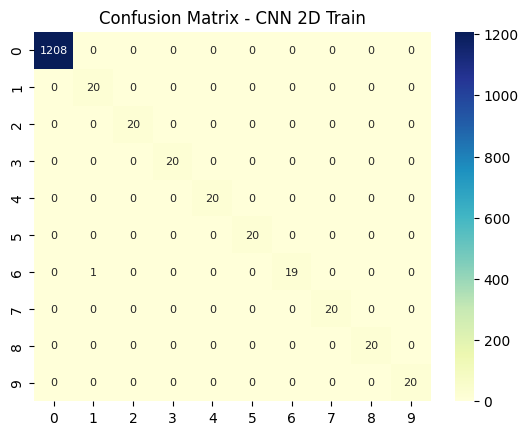

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


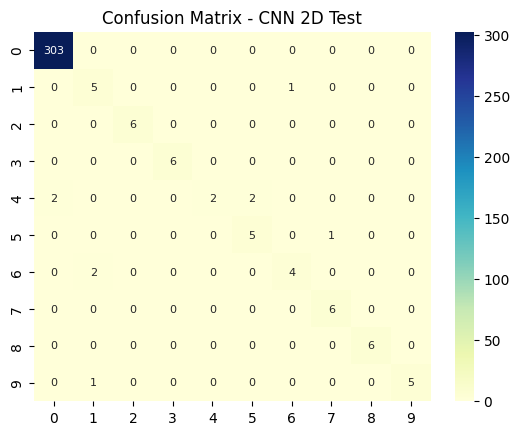

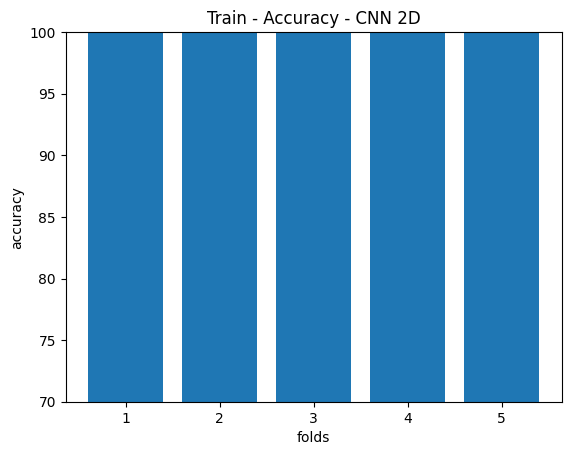

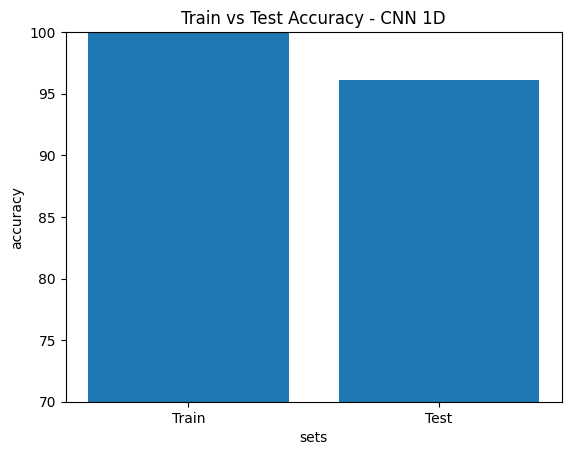

In [49]:
# Aggregated metrics
CNN_2D_train_accuracy = np.mean(accuracy_1D) * 100
CNN_2D_test_accuracy = np.mean(accuracy_1D_test) * 100
CNN_2D_train_precision = np.mean(precision_1D) * 100
CNN_2D_test_precision = np.mean(precision_1D_test) * 100
CNN_2D_train_recall = np.mean(recall_1D) * 100
CNN_2D_test_recall = np.mean(recall_1D_test) * 100
CNN_2D_train_f1 = np.mean(f1_1D) * 100
CNN_2D_test_f1 = np.mean(f1_1D_test) * 100
CNN_2D_train_log_loss = np.mean(log_loss_1D)
CNN_2D_test_log_loss = np.mean(log_loss_1D_test)
CNN_2D_train_balanced_accuracy = np.mean(balanced_accuracy_1D) * 100  # Average balanced accuracy for train set
CNN_2D_test_balanced_accuracy = np.mean(balanced_accuracy_1D_test) * 100  # Average balanced accuracy for test set

# Print metrics
print(f"Train Accuracy: {CNN_2D_train_accuracy:.2f}%")
print(f"Test Accuracy: {CNN_2D_test_accuracy:.2f}%")
print(f"Train Precision: {CNN_2D_train_precision:.2f}%")
print(f"Test Precision: {CNN_2D_test_precision:.2f}%")
print(f"Train Recall: {CNN_2D_train_recall:.2f}%")
print(f"Test Recall: {CNN_2D_test_recall:.2f}%")
print(f"Train F1-score: {CNN_2D_train_recall:.2f}%")
print(f"Test F1-score: {CNN_2D_test_recall:.2f}%")
print(f"Train Log Loss: {CNN_2D_train_log_loss:.4f}")
print(f"Test Log Loss: {CNN_2D_test_log_loss:.4f}")
print(f"Train Balanced Accuracy: {CNN_2D_train_balanced_accuracy:.2f}%")
print(f"Test Balanced Accuracy: {CNN_2D_test_balanced_accuracy:.2f}%")

# Confusion Matrix Calculation

def ConfusionMatrix(Model, X, y):
    y_pred_proba = Model.predict(X)  # Use Model.model instead of Model
    y_pred = np.argmax(y_pred_proba, axis=1)  # Convert probabilities to class labels
    y_true = np.argmax(y, axis=1)  # Convert one-hot labels to class indices
    return confusion_matrix(y_true, y_pred)

# Plot results - CNN 1D
plt.figure(1)
plt.title('Confusion Matrix - CNN 2D Train')
sns.heatmap(ConfusionMatrix(CNN_2D_best_model, X_2D_train, Y_train), annot=True, fmt='d', annot_kws={"fontsize":8}, cmap="YlGnBu")
plt.show()

plt.figure(2)
plt.title('Confusion Matrix - CNN 2D Test')
sns.heatmap(ConfusionMatrix(CNN_2D_best_model, X_2D_test, Y_test), annot=True, fmt='d', annot_kws={"fontsize":8}, cmap="YlGnBu")
plt.show()

plt.figure(3)
plt.title('Train - Accuracy - CNN 2D')
plt.bar(np.arange(1, kSplits + 1), [i * 100 for i in accuracy_1D])
plt.ylabel('accuracy')
plt.xlabel('folds')
plt.ylim([70, 100])
plt.show()

plt.figure(4)
plt.title('Train vs Test Accuracy - CNN 1D')
plt.bar([1, 2], [CNN_2D_train_accuracy, CNN_2D_test_accuracy])
plt.ylabel('accuracy')
plt.xlabel('sets')
plt.xticks([1, 2], ['Train', 'Test'])
plt.ylim([70, 100])
plt.show()